In [1]:
import os
import sys
from pathlib import Path

# Keep BLAS libraries single-threaded in this notebook kernel to avoid startup crashes
# in constrained environments.
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spiceypy

print(sys.executable)
print("SPICE Version:", spiceypy.tkvrsn("TOOLKIT"))

/home/kaushim07/miniforge3/envs/photomc_env/bin/python
SPICE Version: CSPICE_N0067


In [2]:
!hostname

login.curta.zedat.fu-berlin.de


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

geom_root = Path("../data/04_geometry_tables")
phase_order = {"survey": 0, "hamo": 1, "lamo": 2, "rc": 3}

parquet_files = sorted(
    geom_root.glob("*/*_geometry.parquet"),
    key=lambda path: (phase_order.get(path.parent.name.lower(), 99), path.name),
)
if not parquet_files:
    raise FileNotFoundError("No geometry parquet files found in ../data/04_geometry_tables/*")

phase_groups = {phase: [] for phase in phase_order}
for path in parquet_files:
    phase = path.parent.name.lower()
    if phase in phase_groups:
        phase_groups[phase].append(path)

# Build one representative dataframe per phase (largest parquet in that phase).
# Full concatenation of all files is very large, so keep this notebook responsive.
phase_dfs = {}
phase_best_file = {}
for phase in ["survey", "hamo", "lamo", "rc"]:
    files = phase_groups.get(phase, [])
    if not files:
        phase_dfs[phase] = pd.DataFrame()
        phase_best_file[phase] = None
        continue

    best_path = max(files, key=lambda p: p.stat().st_size)
    phase_best_file[phase] = best_path
    phase_dfs[phase] = pd.read_parquet(best_path)

# Expose explicit dataframes per phase for downstream cells.
df_survey = phase_dfs["survey"]
df_hamo = phase_dfs["hamo"]
df_lamo = phase_dfs["lamo"]
df_rc = phase_dfs["rc"]

# Backward compatibility: keep df pointing to survey if present, else first non-empty phase.
df = df_survey
if df.empty:
    for phase in ["hamo", "lamo", "rc"]:
        if not phase_dfs[phase].empty:
            df = phase_dfs[phase]
            break

print(f"Files discovered: {len(parquet_files)}")
for phase in ["survey", "hamo", "lamo", "rc"]:
    phase_df = phase_dfs[phase]
    best_file = phase_best_file[phase]
    print(f"{phase.upper()}: files={len(phase_groups[phase])}, rows={len(phase_df):,}")
    if best_file is not None:
        print(f"  representative file: {best_file.name}")

Files discovered: 1844
SURVEY: files=0, rows=0
HAMO: files=0, rows=0
LAMO: files=1844, rows=1,048,576
  representative file: FC21B0014330_11352082023F1I_geometry.parquet
RC: files=0, rows=0


In [3]:
for phase, phase_df in [("survey", df_survey), ("hamo", df_hamo), ("lamo", df_lamo), ("rc", df_rc)]:
    print(f"\n=== {phase.upper()} ===")
    if phase_df.empty:
        print("No parquet data available for this phase.")
        continue
    display(phase_df.head())
    print(phase_df.describe(include="all"))


=== SURVEY ===
No parquet data available for this phase.

=== HAMO ===
No parquet data available for this phase.

=== LAMO ===


,image_id,pixel_x,pixel_y,iof,incidence,emission,phase,latitude,longitude
0,FC21B0014330_11352082023F1I,0,0,0.026755,55.030079,6.086992,59.153225,0.234924,-2.055403
1,FC21B0014330_11352082023F1I,1,0,0.022315,55.034161,6.080072,59.147892,0.236603,-2.058414
2,FC21B0014330_11352082023F1I,2,0,0.025116,55.038246,6.073158,59.142563,0.238283,-2.061424
3,FC21B0014330_11352082023F1I,3,0,0.025398,55.042332,6.066251,59.137234,0.239962,-2.064435
4,FC21B0014330_11352082023F1I,4,0,0.026089,55.046417,6.059351,59.131901,0.241641,-2.067446


                           image_id       pixel_x       pixel_y           iof  \
count                       1048576  1.048576e+06  1.048576e+06  1.048576e+06   
unique                            1           NaN           NaN           NaN   
top     FC21B0014330_11352082023F1I           NaN           NaN           NaN   
freq                        1048576           NaN           NaN           NaN   
mean                            NaN  5.115000e+02  5.115000e+02  3.619008e-02   
std                             NaN  2.956033e+02  2.956033e+02  1.512419e-02   
min                             NaN  0.000000e+00  0.000000e+00  4.742601e-04   
25%                             NaN  2.557500e+02  2.557500e+02  2.568571e-02   
50%                             NaN  5.115000e+02  5.115000e+02  3.697605e-02   
75%                             NaN  7.672500e+02  7.672500e+02  4.636839e-02   
max                             NaN  1.023000e+03  1.023000e+03  9.076435e-02   

           incidence      e

In [5]:
frames = []
for phase, phase_df in [("survey", df_survey), ("hamo", df_hamo), ("lamo", df_lamo), ("rc", df_rc)]:
    if phase_df.empty:
        continue
    tmp = phase_df.copy()
    tmp["phase_type"] = phase
    frames.append(tmp)

if not frames:
    raise ValueError("No phase dataframes are populated; df_all cannot be created.")

df_all = pd.concat(frames, ignore_index=True)

print(f"df_all rows: {len(df_all):,}")
print("Rows by phase_type:")
print(df_all["phase_type"].value_counts().sort_index())

summary_cols = [c for c in ["iof", "incidence", "emission", "phase"] if c in df_all.columns]
if summary_cols:
    print("\nPer-phase mean values:")
    print(df_all.groupby("phase_type")[summary_cols].mean().round(4))

df_all rows: 1,048,576
Rows by phase_type:
phase_type
lamo    1048576
Name: count, dtype: int64

Per-phase mean values:
               iof  incidence  emission    phase
phase_type                                      
lamo        0.0362  57.520699    4.1176  56.3918


In [7]:
from pathlib import Path

import numpy as np
import pandas as pd

# -----------------------------
# Step 1: Data Ingestion (Memory Safe)
# -----------------------------
rng = np.random.default_rng(42)  # reproducible random selection

base_dir = Path("../data/04_geometry_tables")
survey_dir = base_dir / "survey"
hamo_dir = base_dir / "hamo"

survey_files = sorted(survey_dir.glob("*_geometry.parquet"))
hamo_files = sorted(hamo_dir.glob("*_geometry.parquet"))

if len(survey_files) < 5:
    raise ValueError(f"Need at least 5 survey parquet files, found {len(survey_files)}")
if len(hamo_files) < 5:
    raise ValueError(f"Need at least 5 hamo parquet files, found {len(hamo_files)}")

survey_pick = list(rng.choice(survey_files, size=5, replace=False))
hamo_pick = list(rng.choice(hamo_files, size=5, replace=False))

print("Selected SURVEY files:")
for p in survey_pick:
    print("  ", p.name)

print("Selected HAMO files:")
for p in hamo_pick:
    print("  ", p.name)

# Read only columns needed for this cleaning pass and subsample rows per file.
# This avoids holding 10 full 1024x1024 tables in memory at once.
use_cols = ["image_id", "pixel_x", "pixel_y", "iof", "incidence", "emission", "phase"]
max_rows_per_file = 100_000

frames = []

for phase_name, picks in [("survey", survey_pick), ("hamo", hamo_pick)]:
    for p in picks:
        tmp = pd.read_parquet(p, columns=use_cols)

        if len(tmp) > max_rows_per_file:
            seed = int(rng.integers(0, 2**31 - 1))
            tmp = tmp.sample(n=max_rows_per_file, random_state=seed)

        # Compact dtypes to reduce memory pressure.
        tmp["pixel_x"] = tmp["pixel_x"].astype(np.int16, copy=False)
        tmp["pixel_y"] = tmp["pixel_y"].astype(np.int16, copy=False)
        tmp["iof"] = tmp["iof"].astype(np.float32, copy=False)
        tmp["incidence"] = tmp["incidence"].astype(np.float32, copy=False)
        tmp["emission"] = tmp["emission"].astype(np.float32, copy=False)
        tmp["phase"] = tmp["phase"].astype(np.float32, copy=False)
        tmp["phase_type"] = phase_name

        frames.append(tmp)

df = pd.concat(frames, ignore_index=True)
print(f"\nLoaded rows before cleaning: {len(df):,}")
print("Rows by phase_type before cleaning:")
print(df["phase_type"].value_counts().sort_index())

# -----------------------------
# Step 2: The 'Physics Police' Cleaning
# -----------------------------
def apply_filter(dataframe: pd.DataFrame, keep_mask: pd.Series, label: str) -> pd.DataFrame:
    before = len(dataframe)
    filtered = dataframe.loc[keep_mask].copy()
    after = len(filtered)
    dropped = before - after
    print(f"{label}: dropped {dropped:,} rows (remaining {after:,})")
    return filtered

# 1) Nighttime filter: incidence <= 90
df = apply_filter(df, df["incidence"] <= 90, "incidence > 90 filter")

# 2) Behind-the-rock filter: emission <= 90
df = apply_filter(df, df["emission"] <= 90, "emission > 90 filter")

# 3) Negative light/noise filter: iof >= 0
df = apply_filter(df, df["iof"] >= 0, "iof < 0 filter")

# 4) Cosmic ray / extreme outlier filter: only remove obvious outliers above 25.0
df = apply_filter(df, df["iof"] <= 25.0, "iof > 25.0 filter")

print(f"\nFinal cleaned rows: {len(df):,}")
print("Rows by phase_type after cleaning:")
print(df["phase_type"].value_counts().sort_index())

df_clean = df

ValueError: Need at least 5 survey parquet files, found 0

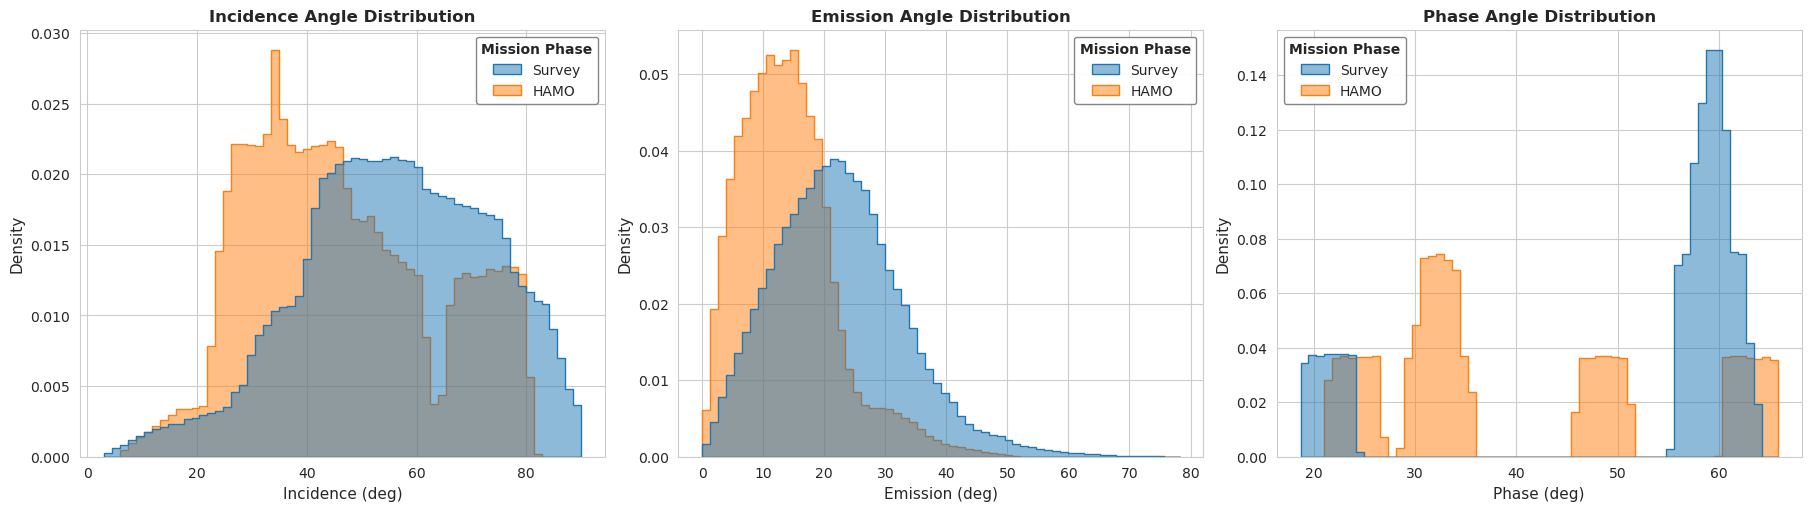

In [8]:

# Use the cleaned dataframe from the previous cell
# Expected columns: incidence, emission, phase, phase_type
plot_df = df_clean.copy()

# Keep only the two mission phases we want to compare
plot_df = plot_df[plot_df["phase_type"].isin(["survey", "hamo"])].copy()

# Optional safety: remove non-finite values in plotted columns
plot_df = plot_df.dropna(subset=["incidence", "emission", "phase", "phase_type"])

palette = {
    "survey": "#1f77b4",  # blue
    "hamo": "#ff7f0e",    # orange
}

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

angle_cols = ["incidence", "emission", "phase"]
titles = ["Incidence Angle Distribution", "Emission Angle Distribution", "Phase Angle Distribution"]
xlabels = ["Incidence (deg)", "Emission (deg)", "Phase (deg)"]

for ax, col, title, xlabel in zip(axes, angle_cols, titles, xlabels, strict=True):
    sns.histplot(
        data=plot_df,
        x=col,
        hue="phase_type",
        stat="density",
        common_norm=False,
        bins=60,
        element="step",
        fill=True,
        alpha=0.5,
        palette=palette,
        ax=ax,
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    
    # Improve legend: get the current legend and customize it
    legend = ax.get_legend()
    if legend:
        # Update legend labels to be more descriptive
        label_map = {"survey": "Survey", "hamo": "HAMO"}
        for text in legend.get_texts():
            old_label = text.get_text()
            # Skip the title, update the data labels
            if old_label in label_map:
                text.set_text(label_map[old_label])
        
        # Style the legend
        legend.set_title("Mission Phase", prop={'size': 10, 'weight': 'bold'})
        legend.get_frame().set_facecolor('white')
        legend.get_frame().set_alpha(0.95)
        legend.get_frame().set_edgecolor('gray')

plt.show()


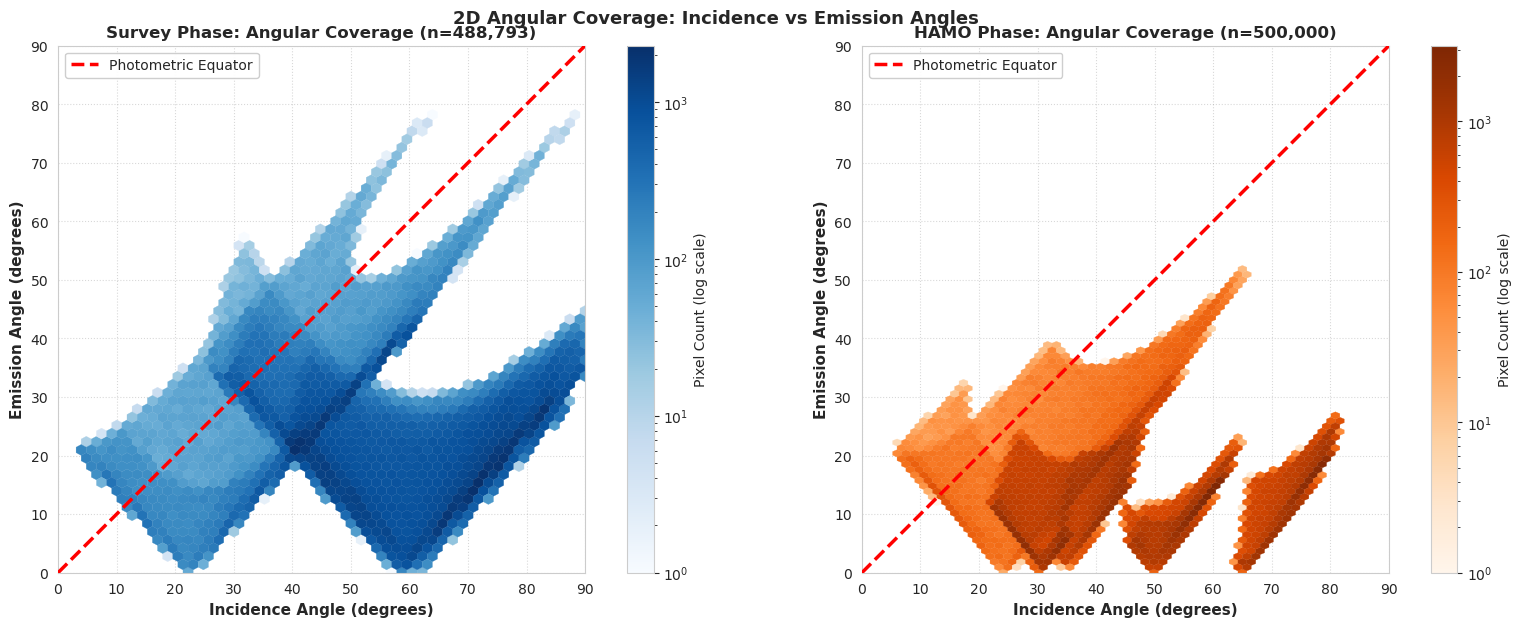


Angular Coverage Summary:
  Survey phase: 488,793 observations
  HAMO phase:   500,000 observations


In [9]:
# 2D Hexbin Density Map: Angular Coverage Analysis
# Visualize photometric equator (incidence = emission) for Hapke model coverage

import numpy as np
from matplotlib.colors import LogNorm

# Prepare data for hexbin visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Create hexbin for Survey and HAMO separately
phases = ['survey', 'hamo']
phase_labels = ['Survey', 'HAMO']
colors_list = ['Blues', 'Oranges']

for _idx, (ax, phase, phase_label, cmap) in enumerate(zip(axes, phases, phase_labels, colors_list, strict=True)):
    # Filter data for this phase
    phase_data = plot_df[plot_df['phase_type'] == phase].copy()
    
    # Create hexbin with logarithmic scale
    hexbin = ax.hexbin(
        phase_data['incidence'],
        phase_data['emission'],
        gridsize=50,  # Size of hexagons
        cmap=cmap,
        norm=LogNorm(),  # Logarithmic color scale
        mincnt=1,  # Minimum counts per hexagon to display
        edgecolors='face',
        linewidths=0.2,
    )
    
    # Draw photometric equator (incidence = emission)
    ax.plot([0, 90], [0, 90], 'r--', linewidth=2.5, label='Photometric Equator', zorder=5)
    
    # Set limits and labels
    ax.set_xlim(0, 90)
    ax.set_ylim(0, 90)
    ax.set_xlabel('Incidence Angle (degrees)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Emission Angle (degrees)', fontsize=11, fontweight='bold')
    ax.set_title(f'{phase_label} Phase: Angular Coverage (n={len(phase_data):,})', 
                 fontsize=12, fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(hexbin, ax=ax)
    cbar.set_label('Pixel Count (log scale)', fontsize=10)
    
    # Add grid for reference
    ax.grid(True, alpha=0.3, linestyle=':', color='gray')
    ax.set_aspect('equal')
    
    # Add legend for photometric equator
    ax.legend(loc='upper left', fontsize=10, framealpha=0.95)

plt.suptitle('2D Angular Coverage: Incidence vs Emission Angles', 
             fontsize=13, fontweight='bold', y=1.02)
plt.show()

print("\nAngular Coverage Summary:")
print(f"  Survey phase: {len(plot_df[plot_df['phase_type'] == 'survey']):,} observations")
print(f"  HAMO phase:   {len(plot_df[plot_df['phase_type'] == 'hamo']):,} observations")

In [10]:
# Reload RAW data - NO FILTERS APPLIED

rng = np.random.default_rng(42)

base_dir = Path("../data/04_geometry_tables")
survey_dir = base_dir / "survey"
hamo_dir = base_dir / "hamo"

survey_files = sorted(survey_dir.glob("*_geometry.parquet"))
hamo_files = sorted(hamo_dir.glob("*_geometry.parquet"))

survey_pick = list(rng.choice(survey_files, size=5, replace=False))
hamo_pick = list(rng.choice(hamo_files, size=5, replace=False))

# Read ALL columns, NO subsampling, NO filters
use_cols = ["image_id", "pixel_x", "pixel_y", "iof", "incidence", "emission", "phase"]
frames_raw = []

for _phase_name, picks in [("survey", survey_pick), ("hamo", hamo_pick)]:
    for p in picks:
        tmp = pd.read_parquet(p, columns=use_cols)
        frames_raw.append(tmp)

df_raw = pd.concat(frames_raw, ignore_index=True)

print("=== RAW DATA (NO FILTERS APPLIED) ===")
print(f"Total row count: {len(df_raw):,}")
print("\nIOF Statistics:")
print(f"  Min:    {df_raw['iof'].min():.6f}")
print(f"  Max:    {df_raw['iof'].max():.6f}")
print(f"  Median: {df_raw['iof'].median():.6f}")
print(f"\nObservations with iof > 1.0: {(df_raw['iof'] > 1.0).sum():,}")
print(f"% exceeding unity: {100 * (df_raw['iof'] > 1.0).sum() / len(df_raw):.2f}%")

=== RAW DATA (NO FILTERS APPLIED) ===
Total row count: 10,485,760

IOF Statistics:
  Min:    0.000000
  Max:    0.000017
  Median: 0.000007

Observations with iof > 1.0: 0
% exceeding unity: 0.00%


Rows in df_center: 117,031


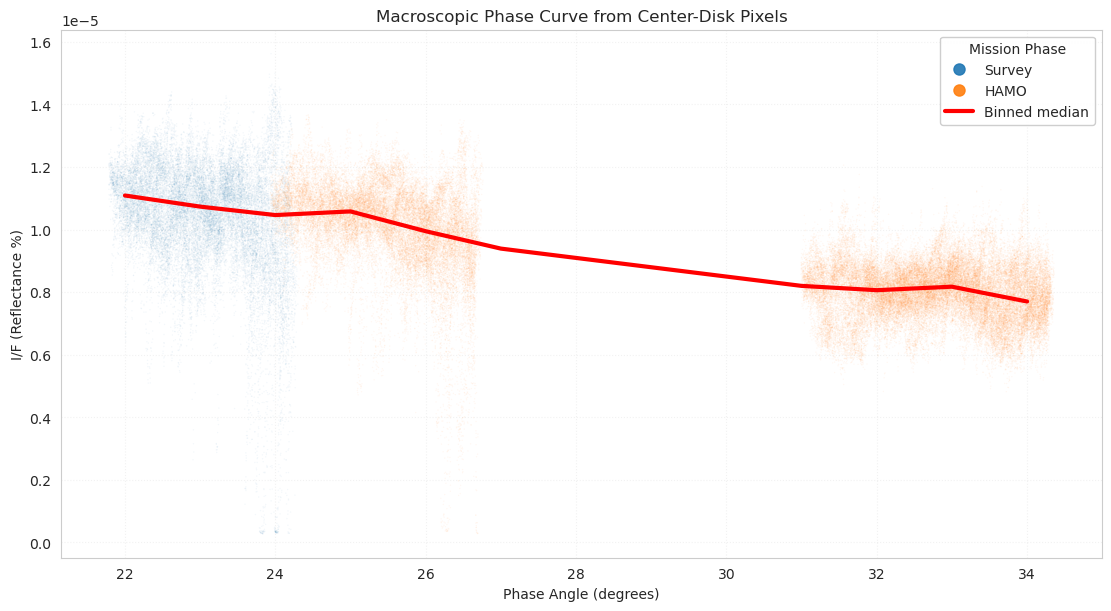

In [11]:
# Macroscopic Phase Curve: Opposition Effect / Li et al. (2013) comparison
# Center-disk subset removes limb-darkening contributions so the phase curve is closer to the intrinsic surface response.

from matplotlib.lines import Line2D

df_center = df_clean.loc[
    (df_clean["incidence"] < 30) & (df_clean["emission"] < 30)
].copy()

print(f"Rows in df_center: {len(df_center):,}")

# Phase-angle binning for a robust trendline
phase_bins = (
    df_center["phase"]
    .astype(float)
    .round()
    .astype(int)
)

trend_df = (
    df_center.assign(phase_bin=phase_bins)
    .groupby("phase_bin", as_index=False)["iof"]
    .median()
    .rename(columns={"phase_bin": "phase", "iof": "median_iof"})
    .sort_values("phase")
)

# Plot scatter cloud + binned median trendline
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

palette = {"survey": "#1f77b4", "hamo": "#ff7f0e"}

sns.scatterplot(
    data=df_center,
    x="phase",
    y="iof",
    hue="phase_type",
    palette=palette,
    s=1,
    alpha=0.05,
    linewidth=0,
    legend=False,
    ax=ax,
)

ax.plot(
    trend_df["phase"],
    trend_df["median_iof"],
    color="red",
    linewidth=3,
    linestyle="-",
    label="Binned median",
    zorder=5,
)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=palette["survey"],
        markeredgecolor=palette["survey"],
        markersize=8,
        alpha=0.9,
        label="Survey",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=palette["hamo"],
        markeredgecolor=palette["hamo"],
        markersize=8,
        alpha=0.9,
        label="HAMO",
    ),
    Line2D(
        [0],
        [0],
        color="red",
        linewidth=3,
        label="Binned median",
    ),
]

ax.set_xlabel("Phase Angle (degrees)")
ax.set_ylabel("I/F (Reflectance %)")
ax.set_title("Macroscopic Phase Curve from Center-Disk Pixels")
ax.legend(handles=legend_handles, title="Mission Phase", loc="best", framealpha=0.95)
ax.grid(True, alpha=0.25, linestyle=":")

plt.show()
